In [2]:
import os
import json
from urllib.parse import unquote
from DocMiner import DocMiner, Task
from DocMinerPreprocess import DocMinerPreprocess
# from azure.ai.documentintelligence.models import AnalyzeResult 
from openai import AzureOpenAI
import networkx as nx  
import matplotlib.pyplot as plt  

sync_openai = AzureOpenAI(
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_API_URL"),
    max_retries=3,
    timeout=30
)

docminer_preprocess = DocMinerPreprocess()

In [3]:
documents = []

doc_dir = "../linked_docs_v0"
for file in os.listdir(doc_dir):
    if file.endswith(".docx"):
        print(file)
        documents.append(docminer_preprocess.create_docminer(source_file_full_path = os.path.join(doc_dir, file)))



Plan for Model Training Using Azure Machine Learning Service_V0.docx


HttpResponseError: Key based authentication is not permitted on this storage account.
RequestId:fac39968-401e-006a-446b-9e02d9000000
Time:2025-03-26T16:25:13.2779411Z
ErrorCode:KeyBasedAuthenticationNotPermitted
Content: <?xml version="1.0" encoding="utf-8"?><Error><Code>KeyBasedAuthenticationNotPermitted</Code><Message>Key based authentication is not permitted on this storage account.
RequestId:fac39968-401e-006a-446b-9e02d9000000
Time:2025-03-26T16:25:13.2779411Z</Message></Error>

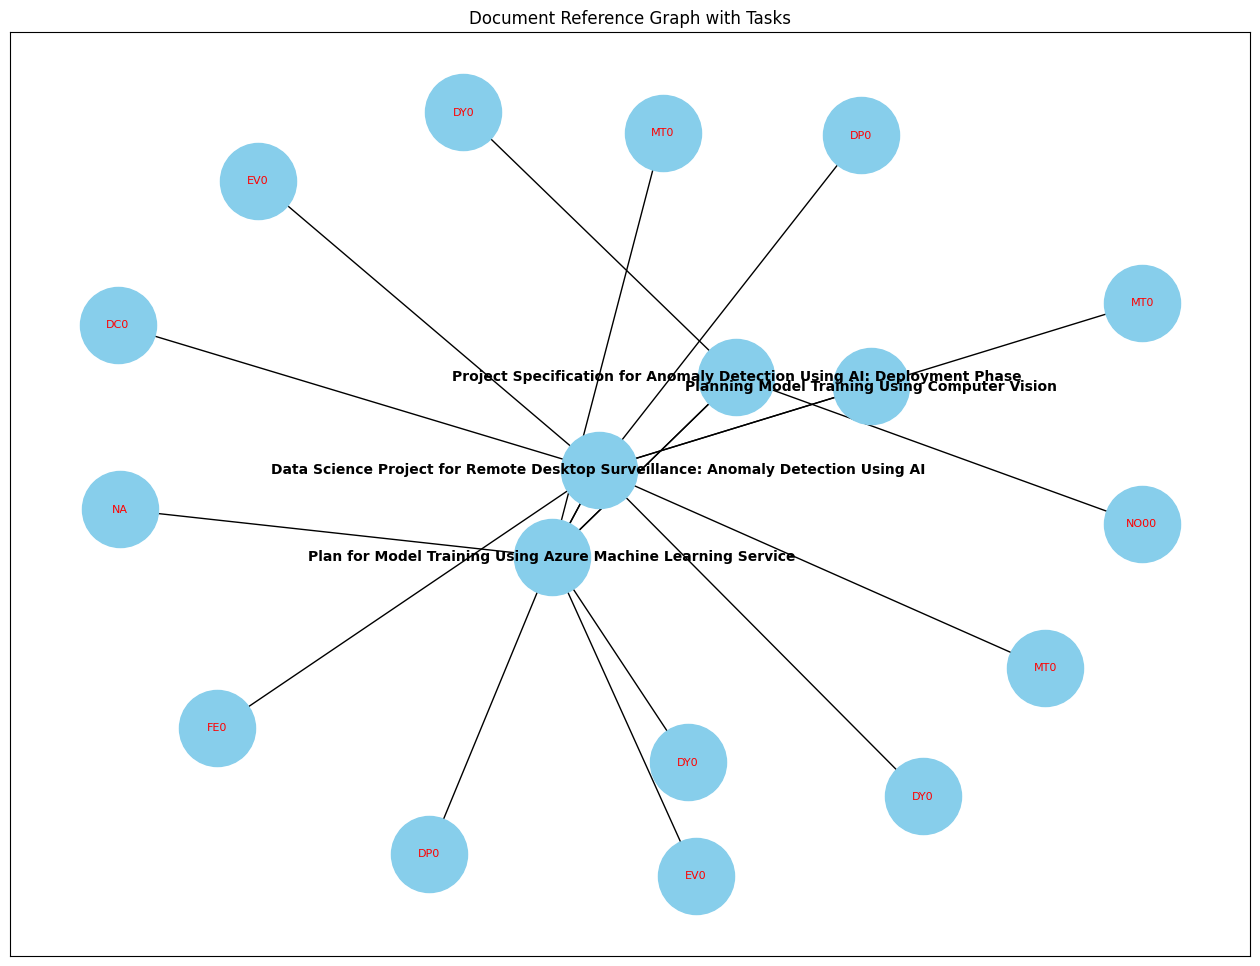

In [ ]:
G = DocMiner.create_graph(documents)

DocMiner.draw_graph(G)

In [ ]:
# Find document IDs by task code  
task_code = 'MT0'  
document_ids_by_task_code = DocMiner.get_document_ids_by_task_codes(G, task_code)  
for doc_id in document_ids_by_task_code:
    node = DocMiner.get_node_by_id(G, doc_id)
    print(f"Document IDs for task code {task_code}: related file is {node}")

Document IDs for task code MT0: Plan for Model Training Using Azure Machine Learning Service_V0.docx
Document IDs for task code MT0: Project Data Science Project for Remote Desktop Surveillance_v0.docx
Document IDs for task code MT0: Planning Model Training Using Computer Vision v0.docx


In [ ]:
# Find top document ID  
top_document_id = DocMiner.find_top_document_id(G)  
print(f"Top Document ID (most hierarchical/top POV): {top_document_id}")  
  

Top Document ID (most hierarchical/top POV): db0a8d80-e4f3-4055-9dd3-deb31ac5d8f6


## New document

In [ ]:
updated_doc = []

doc_dir = "../linked_docs_v1"
for file in os.listdir(doc_dir):
    if file.endswith(".docx"):
        print(file)
        updated_doc.append(docminer_preprocess.create_docminer(source_file_full_path = os.path.join(doc_dir, file)))

updated_doc

Project Data Science Project for Remote Desktop Surveillance_v1.docx


[DocMiner(document_id='475c0b88-e522-42dd-9667-b5e478dd62fb', document_filename='Project Data Science Project for Remote Desktop Surveillance_v1.docx', file_location='https://openaiembedding.blob.core.windows.net/docminer-container/Project Data Science Project for Remote Desktop Surveillance_v1.docx', project_title='Data Science Project for Remote Desktop Surveillance: Anomaly Detection Using AI', author='Unknown', table_of_contents=['Purpose', 'Project Description', 'Intended Users', 'Model Development Environment', 'Potential Business Impact'], keywords=['Remote Desktop Surveillance', 'Anomaly Detection', 'Artificial Intelligence', 'Video Feeds', 'Model Training', 'Data Collection', 'Data Preprocessing', 'Feature Extraction', 'Evaluation and Validation', 'Deployment', 'IT Security', 'System Administrators', 'Data Analysts', 'Machine Learning', 'TensorFlow', 'PyTorch', 'OpenCV', 'Scikit-learn', 'Jupyter Notebooks', 'AWS', 'Google Cloud', 'Git', 'Data Lakes'], tasks=[Task(task_code='DC

In [ ]:
for g in G:
    # print(f"{g} -{type(g)}")
    g


Plan for Model Training Using Azure Machine Learning Service_V0.docx -<class 'str'>
Project Data Science Project for Remote Desktop Surveillance_v0.docx -<class 'str'>
Project Specification for AI Deployment Phase.docx -<class 'str'>
Planning Model Training Using Computer Vision v0.docx -<class 'str'>
Plan for Model Training Using Azure Machine Learning Service_V0.docx_DP0 -<class 'str'>
Plan for Model Training Using Azure Machine Learning Service_V0.docx_MT0 -<class 'str'>
Plan for Model Training Using Azure Machine Learning Service_V0.docx_EV0 -<class 'str'>
Plan for Model Training Using Azure Machine Learning Service_V0.docx_DY0 -<class 'str'>
Plan for Model Training Using Azure Machine Learning Service_V0.docx_NA -<class 'str'>
Planning Model Training Using Computer Vision v0.docx_MT0 -<class 'str'>
Project Data Science Project for Remote Desktop Surveillance_v0.docx_DC0 -<class 'str'>
Project Data Science Project for Remote Desktop Surveillance_v0.docx_DP0 -<class 'str'>
Project D

In [ ]:
def find_diff_beteen_task(base, target: list[DocMiner]):
    diff = []
    
    print(base)
    # get task code from target
    for doc in target:
        for task in doc.tasks:
            print(task)
            if task.task_code not in base.task_codes:
                continue
            else:
                # if task description is different
                if base.task_codes[task_code].task_description != doc.task_codes[task_code].task_description:
                    diff.append((task_code, base.task_codes[task_code].task_description, doc.task_codes[task_code].task_description))
                    
    return diff

find_diff_beteen_task(G, updated_doc)


DiGraph with 18 nodes and 20 edges
task_code='DC0' task_description='Recording and gathering video feeds from various remote desktop sessions.'


AttributeError: 'DiGraph' object has no attribute 'task_codes'